In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from astropy.io import fits
import matplotlib.gridspec as gridspec
import pickle
import os,sys
from pathlib import Path
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent
functions_path = project_root / "functions"
sys.path.append(str(functions_path))
import stats_circular as stats


data_dir = "/home/ymascolo/Desktop/github/datasets" # path datsets

# Transit plots for LHS 6050 system


In [2]:
# JSON file with the best fit parameters from the global fit
# ===================
with open(os.path.join(data_dir,"best_fit_results.json")) as f:
    data = json.load(f)

fp = data['fitted_parameters']

theta_best = [
    fp['t_0']['median'],    
    fp['P']['median'],
    fp['R_p/R_s']['median'],
    fp['b']['median'],
    fp['mstar']['median'],
    fp['rstar']['median'],
    fp['q1_{tess}']['median'],    
    fp['q2_{tess}']['median'],
    fp['q1_{lco}']['median'],    
    fp['q2_{lco}']['median'],
    fp['q1_{lcog}']['median'],    
    fp['q2_{lcog}']['median'],
    fp['q1_{minerva}']['median'],    
    fp['q2_{minerva}']['median'],
    fp['q1_{ngts}']['median'],    
    fp['q2_{ngts}']['median'],
    fp['q1_{trap}']['median'],    
    fp['q2_{trap}']['median']
]

t0, per = theta_best[0], theta_best[1]
rp, b    = theta_best[2], theta_best[3]
mstar, rstar = theta_best[4], theta_best[5]
q1_tess, q2_tess, q1_lco, q2_lco, q1_lcog, q2_lcog, q1_minerva, q2_minerva = theta_best[6], theta_best[7],theta_best[8], theta_best[9], theta_best[10], theta_best[11], theta_best[12], theta_best[13]
q1_ngts, q2_ngts, q1_trap, q2_trap =  theta_best[14], theta_best[15], theta_best[16], theta_best[17]

In [3]:
# Load the processed datasets (see processed_data.py for detailes)
# ====================================================================
with open(os.path.join(data_dir, "processed_data/LHS6050b_global_data.pkl"), "rb") as f:
    data_loaded = pickle.load(f)

tess_data     = data_loaded["tess_data"]
lco_data      = data_loaded["lco_data"]
lcog_data     = data_loaded["lcog_data"]
trap_data     = data_loaded["trap_data"]
minerva_data  = data_loaded["minerva_data"]
ngts_data     = data_loaded["ngts_data"]


### Phase folded plot

In [4]:
# Useful plot functions
# ==============================

# ----------Phase binning function--------------

def phase_bin(phase, flux, bin_width):
    
    bins = np.arange(-0.5, 0.5 + bin_width, bin_width)
    ind = np.digitize(phase, bins)

    phase_binned = []
    flux_binned = []
    err_binned = []

    for i in range(1, len(bins)):
        m = ind == i
        if np.sum(m) > 0:
            phase_binned.append(np.mean(phase[m]))
            flux_binned.append(np.mean(flux[m]))
            err_binned.append(np.std(flux[m]) / np.sqrt(np.sum(m)))

    return (np.array(phase_binned), np.array(flux_binned), np.array(err_binned))



# ---------Merge datasets function----------

def merge_datasets(data_list, loglike_function, theta_best):

    phase_list = []
    flux_list = []
    model_list = []

    for dataset in data_list:
        time = dataset["time"]
        flux = dataset["flux"]

        # phase folding
        phase = ((time - theta_best[0]) % theta_best[1]) / theta_best[1]
        phase[phase > 0.5] -= 1

        _, transit_bf, trend_bf = loglike_function(theta_best, dataset)
        flux_detrended = flux - trend_bf

        phase_list.append(phase)
        flux_list.append(flux_detrended)
        model_list.append(transit_bf)

    # concatenate dataset
    phase_all = np.concatenate(phase_list)
    flux_all = np.concatenate(flux_list)
    model_all = np.concatenate(model_list)

    # phase order
    idx = np.argsort(phase_all)
    phase_all = phase_all[idx]
    flux_all = flux_all[idx]
    model_all = model_all[idx]

    return phase_all, flux_all, model_all

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


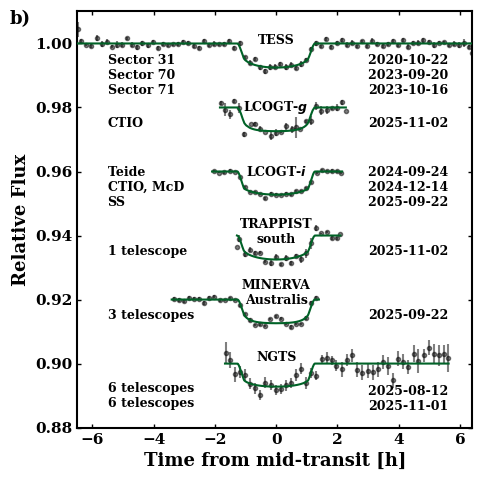

In [5]:
# Phase folded plot
# =======================

colors = sns.color_palette("Greens", 10)

# phase-folding parameters
duration = 2.148/24 
cadence_days = 10 / (24 * 60)   # days
bin_width = cadence_days / per

# vertical offset step
offset_step = 0.0
n = 0.02

phase_to_hours = lambda ph: ph * per * 24

plt.figure(figsize=(5,5))

plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})


# -----------TESS data------------

phase_tess, flux_all, model = merge_datasets(tess_data, stats.tess_transit_log_likelihood_sector, theta_best)
flux = flux_all + offset_step  # apply vertical offset
ph_bin, fl_bin, err_bin = phase_bin(phase_tess, flux, bin_width)
ph_bin = phase_to_hours(ph_bin)
phase_tess = phase_to_hours(phase_tess)

plt.errorbar(ph_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.5, color="k", ms=3)
# plt.plot(phase, flux, ".", ms=3, alpha=0.2, color="grey", label=f"TESS {sector['sector']}")
plt.plot(phase_tess, model + offset_step, "-", lw=1.5, color=colors[9], zorder=5)  # best-fit transit
plt.text(0.0, 1.001, 'TESS', fontsize=9, fontweight="bold", va="center", ha="center")
plt.text(-5.5, 0.99, 'Sector 31 \nSector 70 \nSector 71', 
         fontsize=9, va="center", ha="left")
plt.text(3, 0.99, '2020-10-22 \n2023-09-20 \n2023-10-16', 
         fontsize=9, va="center", ha="left")

offset_step -= n

# ----------LCOG data--------------- 

phase, flux_all, model = merge_datasets(lcog_data, stats.lcog_transit_log_likelihood_dataset, theta_best)
flux = flux_all + offset_step  # apply vertical offset
ph_bin, fl_bin, err_bin = phase_bin(phase, flux, bin_width)
ph_bin = phase_to_hours(ph_bin)
phase = phase_to_hours(phase)

plt.errorbar(ph_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.5, color="k", ms=3)
# plt.plot(phase, flux, ".", ms=3, alpha=0.2, color="grey", label=f"TESS {sector['sector']}")
plt.plot(phase, model + offset_step, "-", lw=1.5, color=colors[9], zorder=5)  # best-fit transit
plt.text(0.0, 0.98, 'LCOGT-$g$', fontsize=9, fontweight="bold", va="center", ha="center")
# plt.text(-5.5, 0.975, 'TO, $Sloan \, i’$ \nCTIO, MDO, $Sloan \, i’$ \nSS, $Sloan \, i’$', 
#          fontsize=9, va="center", ha="left")
plt.text(-5.5, 0.975, 'CTIO', 
         fontsize=9, va="center", ha="left")
plt.text(3, 0.975, '2025-11-02', 
         fontsize=9, va="center", ha="left")

offset_step -= n

# ---------------LCO data-------------

phase, flux_all, model = merge_datasets(lco_data, stats.lco_transit_log_likelihood_dataset, theta_best)
flux = flux_all + offset_step  # apply vertical offset
ph_bin, fl_bin, err_bin = phase_bin(phase, flux, bin_width)
ph_bin = phase_to_hours(ph_bin)
phase = phase_to_hours(phase)

plt.errorbar(ph_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.5, color="k", ms=3)
# plt.plot(phase, flux, ".", ms=3, alpha=0.2, color="grey", label=f"TESS {sector['sector']}")
plt.plot(phase, model + offset_step, "-", lw=1.5, color=colors[9], zorder=5)  # best-fit transit
plt.text(0.0, 0.96, 'LCOGT-$i$', fontsize=9, fontweight="bold", va="center", ha="center")
# plt.text(-5.5, 0.975, 'TO, $Sloan \, i’$ \nCTIO, MDO, $Sloan \, i’$ \nSS, $Sloan \, i’$', 
#          fontsize=9, va="center", ha="left")
plt.text(-5.5, 0.955, 'Teide \nCTIO, McD \nSS', 
         fontsize=9, va="center", ha="left")
plt.text(3, 0.955, '2024-09-24  \n2024-12-14 \n2025-09-22 ', 
         fontsize=9, va="center", ha="left")


offset_step -= n

# --------------TRAPPIST data--------------- 

phase, flux_all, model = merge_datasets(trap_data, stats.trap_transit_log_likelihood_dataset, theta_best)
flux = flux_all + offset_step  # apply vertical offset
ph_bin, fl_bin, err_bin = phase_bin(phase, flux, bin_width)
ph_bin = phase_to_hours(ph_bin)
phase = phase_to_hours(phase)

plt.errorbar(ph_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.5, color="k", ms=3)
# plt.plot(phase, flux, ".", ms=3, alpha=0.2, color="grey", label=f"TESS {sector['sector']}")
plt.plot(phase, model + offset_step, "-", lw=1.5, color=colors[9], zorder=5)  # best-fit transit
plt.text(0.0, 0.941, 'TRAPPIST\nsouth', fontsize=9, fontweight="bold", va="center", ha="center")
# plt.text(-5.5, 0.975, 'TO, $Sloan \, i’$ \nCTIO, MDO, $Sloan \, i’$ \nSS, $Sloan \, i’$', 
#          fontsize=9, va="center", ha="left")
plt.text(-5.5, 0.935, '1 telescope', 
         fontsize=9, va="center", ha="left")
plt.text(3, 0.935, '2025-11-02', 
         fontsize=9, va="center", ha="left")


offset_step -= n

#------------Minerva data--------------

phase, flux_all, model = merge_datasets(minerva_data, stats.minerva_transit_log_likelihood_dataset, theta_best)
flux = flux_all + offset_step  # apply vertical offset
ph_bin, fl_bin, err_bin = phase_bin(phase, flux, bin_width)
ph_bin = phase_to_hours(ph_bin)
phase = phase_to_hours(phase)

plt.errorbar(ph_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.5, color="k", ms=3)
# plt.plot(phase, flux, ".", ms=3, alpha=0.2, color="grey", label=f"TESS {sector['sector']}")
plt.plot(phase, model + offset_step, "-", lw=1.5, color=colors[9], zorder=5)  # best-fit transit
plt.text(0.0, 0.922, 'MINERVA\nAustralis', fontsize=9, fontweight="bold", va="center", ha="center")
plt.text(-5.5, 0.915, '3 telescopes', fontsize=9, va="center", ha="left")
plt.text(3, 0.915, '2025-09-22', fontsize=9, va="center", ha="left")


offset_step -= n

# ----------NGTS data---------------

phase, flux_all, model = merge_datasets(ngts_data, stats.ngts_transit_log_likelihood_dataset, theta_best)
flux = flux_all + offset_step  # apply vertical offset
ph_bin, fl_bin, err_bin = phase_bin(phase, flux, bin_width)
ph_bin = phase_to_hours(ph_bin)
phase = phase_to_hours(phase)

plt.errorbar(ph_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.5, color="k", ms=3)
#plt.plot(phase, flux, ".", ms=3, alpha=0.2, color="grey", label=f"TESS {sector['sector']}")
plt.plot(phase, model + offset_step, "-", lw=1.5, color=colors[9], zorder=5)  # best-fit transit
plt.text(0.0, 0.902, 'NGTS', fontsize=9, fontweight="bold", va="center", ha="center")
plt.text(-5.5, 0.89, '6 telescopes \n6 telescopes', fontsize=9, va="center", ha="left")
plt.text(3, 0.889, '2025-08-12 \n2025-11-01', fontsize=9, va="center", ha="left")



plt.xlabel("Time from mid-transit [h]")
plt.ylabel("Relative Flux")

ax = plt.gca()
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_linewidth(1.5)
    ax.spines[side].set_edgecolor('black')
ax.grid(False)
ax.set_facecolor('white')
ax.tick_params(axis='both', which='major', labelsize=11,
               width=1, length=3, color='black', direction='in', top=True, right=True)
ax.text(-0.17, 0.97, 'b)', fontsize=13, transform=ax.transAxes)

#plt.title("Phase-folded transit stacked plot")
plt.ylim(0.88, 1.01)
plt.xlim(phase_tess.min(), phase_tess.max())
plt.tight_layout()
# plt.savefig('LC.pdf', dpi=300, bbox_inches='tight')
plt.show()


### Single transits plot

In [6]:
# Data setup for single light curve olots
#====================== 
label_tess = ('$tess$-band, \n2020-10-22', '$tess$-band, \n2023-09-20', '$tess$-band, \n2023-10-16')
label_minerva = ('\n2025-09-22', '\n2025-09-22', '\n2025-09-22')
label_ngts = ('\n$ngts$-band, 2025-08-12', '\n$ngts$-band, 2025-08-12', '\n$ngts$-band, 2025-08-12', '\n$ngts$-band, 2025-08-12', '\n$ngts$-band, 2025-08-12', '\n$ngts$-band, 2025-08-12', 
             '\n$ngts$-band, 2025-11-01', '\n$ngts$-band, 2025-11-01', '\n$ngts$-band, 2025-11-01', '\n$ngts$-band, 2025-11-01', '\n$ngts$-band, 2025-11-01', '\n$ngts$-band, 2025-11-01')
label_lco = ( '$i$-band, \n2025-09-22', '$i$-band, \n2024-09-24', '$i$-band, \n2024-12-14', '$i$-band, \n2024-12-14')
label_lcog = ('$g$-band, \n2025-11-02', '$g$-band, \n2025-11-02')
label_trap = ('$R$-band, \n2025-11-02', '$R$-band, \n2025-11-02')


all_data = [tess_data, minerva_data, ngts_data, lco_data, lcog_data, trap_data]
all_labels = [label_tess, label_minerva, label_ngts, label_lco, label_lcog,  label_trap]
all_t_consts = [(2164, 3214, 3254), (3941, 3941, 3941), 
                (3900, 3900, 3900, 3900, 3900, 3900, 3981, 3981, 3981, 3981, 3981, 3981),
                ( 3659, 3941, 3578, 3658), (3981, 3981)]
source_names = ["TESS Sector", "MINERVA-Australis", "NGTS", "LCOGT", "LCOGT", "TRAPPIST-"]

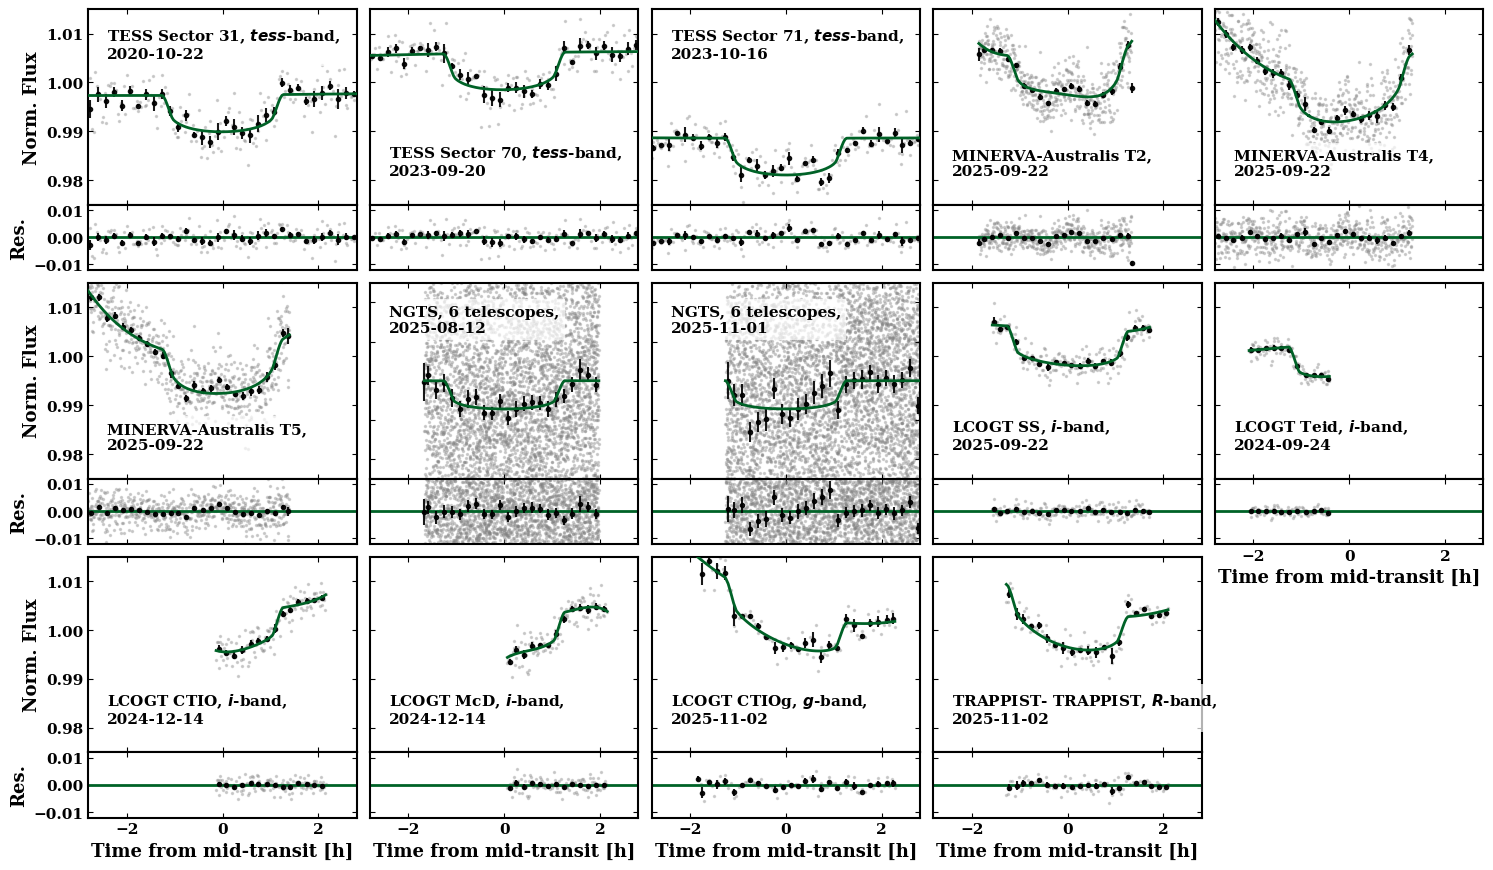

In [7]:
# Useful plot functions
# ==============================

# --------Bin in time----------
def time_bin(time, flux, bin_width_hours):

    bins = np.arange(-3.5, 3.5 + bin_width_hours, bin_width_hours)
    ind = np.digitize(time, bins)

    time_binned = []
    flux_binned = []
    err_binned = []

    for i in range(1, len(bins)):
        m = ind == i
        if np.sum(m) > 0:
            time_binned.append(np.mean(time[m]))
            flux_binned.append(np.mean(flux[m]))
            std = np.std(flux[m])

            err_binned.append(std / np.sqrt(np.sum(m)) if np.sum(m) > 1 else 0.001)

    return (np.array(time_binned), np.array(flux_binned), np.array(err_binned))


# -----------plot function---------
def plot_transit_cell(gs_spec, x, y, y_model, label, is_first_col, bin_width, show_x_labels=False, dx=0.07, dy=0.15):

    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_spec, height_ratios=[3, 1], hspace=0.0)
    
    ax1 = fig.add_subplot(inner_gs[0])
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)

    t_bin, fl_bin, err_bin = time_bin(x, y, bin_width)

    # binning residuals
    residuals = y - y_model
    t_res_bin, res_bin, res_err_bin = time_bin(x, residuals, bin_width)
    
    # plots model+data points
    ax1.plot(x, y, ".", ms=3, alpha=0.3, color="gray", zorder=1, rasterized=True)
    ax1.plot(x, y_model, "-", lw=2, color=colors[9], zorder=3, rasterized=True)
    ax1.errorbar(t_bin, fl_bin, yerr=err_bin, fmt="o", alpha=0.9, color="k", ms=3, zorder=2, rasterized=True)
    
    # Residuals
    ax2.plot(x, residuals, ".", ms=3, alpha=0.3, color="gray", rasterized=True)
    ax2.axhline(0, color=colors[9], ls="-", lw=2)
    ax2.errorbar(t_res_bin, res_bin, yerr=res_err_bin, fmt="o", alpha=0.9, color="k", ms=3, zorder=3, capsize=0,rasterized=True)

    # Labeling, limits and axes
    ax1.text(dx, dy, label, fontsize=11, transform=ax1.transAxes,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax1.set_xlim(-window_days, window_days)

    for ax in [ax1, ax2]:
        for side in ['top', 'bottom', 'left', 'right']:
            ax.spines[side].set_linewidth(1.5)
        ax.tick_params(axis='both', which='major', labelsize=11, direction='in', top=True, right=True)
  
        if not is_first_col:
            plt.setp(ax.get_yticklabels(), visible=False)

    if show_x_labels:
        ax2.set_xlabel("Time from mid-transit [h]")
    else:
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), visible=False)
            
    ax1.set_ylabel("Norm. Flux") if is_first_col else None
    ax2.set_ylabel("Res.") if is_first_col else None
    
    plt.setp(ax1.get_xticklabels(), visible=False) 
        
    return ax1, ax2

# -----Data configuration-------
likelihood_map = {
    "TESS Sector": stats.tess_transit_log_likelihood_sector,
    "MINERVA-Australis": stats.minerva_transit_log_likelihood_dataset,
    "NGTS": stats.ngts_transit_log_likelihood_dataset,
    "LCOGT": stats.lco_transit_log_likelihood_dataset,
    "LCOGTg": stats.lcog_transit_log_likelihood_dataset,
    "TRAPPIST-": stats.trap_transit_log_likelihood_dataset
}

# Define NGTS groups explicitly
ngts_merged_configs = [
    {'data': ngts_data[:6], 'label': 'NGTS, 6 telescopes,\n2025-08-12', 't_const': 3900},
    {'data': ngts_data[6:], 'label': 'NGTS, 6 telescopes,\n2025-11-01', 't_const': 3981}
]


#-------plot loop------------
ncols = 5
nrows = 3 

fig = plt.figure(figsize=(18, 3.5 * nrows))
outer_gs = gridspec.GridSpec(nrows, ncols, wspace=0.05, hspace=0.05)
current_idx = 0
total_plots = 14

t0_best = theta_best[0]
window_days = 2.8

bin_width = 10/60

for d_idx, data_group in enumerate(all_data):
    source = source_names[d_idx]
    
    # CASE A: NGTS (Merged)
    if source == "NGTS":
        for config in ngts_merged_configs:
            phase, flux, model = merge_datasets(config['data'], likelihood_map[source], theta_best)
            
            t_plot = (phase * theta_best[1])*24
            
            ax1, ax2 = plot_transit_cell(outer_gs[current_idx // ncols, current_idx % ncols],
                                         t_plot, flux, model, config['label'], 
                                         (current_idx % ncols == 0), bin_width, show_x_labels=show_x, dy=0.75)
            ax1.set_ylim(0.975, 1.025)
            current_idx += 1
            ax1.set_xlim(-window_days, window_days)
            ax2.set_ylim(-0.012, 0.012)

    # CASE B: ALL OTHER INSTRUMENTS
    else:
        for i, dataset in enumerate(data_group):
            # Dynamic Labeling
            prefix = f"{source} {dataset.get('sector', dataset.get('dataset', ''))}"
            label = f"{prefix}, {all_labels[d_idx][i]}"
            
            # Calculate Model
            _, transit_bf, trend_bf = likelihood_map[source](theta_best, dataset)

            t_plot = (dataset["time"] - t0_best)
            
            period = theta_best[1]
            t_plot = (((t_plot + 0.5 * period) % period) - 0.5 * period)

            show_x = (current_idx >= total_plots - 5)

            if current_idx == 0 or current_idx == 2:
                ax1, ax2 = plot_transit_cell(outer_gs[current_idx // ncols, current_idx % ncols],
                                         t_plot*24, dataset["flux"], transit_bf + trend_bf, 
                                         label, (current_idx % ncols == 0), bin_width, show_x_labels=show_x, dy=0.75)
            
            else:
                ax1, ax2 = plot_transit_cell(outer_gs[current_idx // ncols, current_idx % ncols],
                                         t_plot*24, dataset["flux"], transit_bf + trend_bf, 
                                         label, (current_idx % ncols == 0), bin_width, show_x_labels=show_x)
            
            ax1.set_ylim(0.975, 1.015)
            ax1.set_xlim(-window_days, window_days)
            ax2.set_ylim(-0.012, 0.012)
            current_idx += 1
# plt.savefig('all_transits.pdf', dpi=300)
plt.show()

### TESS sectors plot

In [8]:
# TESS datasets
# ================================


# -------Load TESS sectors function------------
def tess_sector(filename):
    
    hdul = fits.open(filename)
    
    if "LIGHTCURVE" in hdul[1].name:
        hdu = hdul[1]
    else:
        raise ValueError("Light curve HDU not found")
    
    data = hdu.data
    hdr  = hdu.header

    quality_mask = (data["QUALITY"] == 0)
    
    # time, sap flux masked 
    time = data["TIME"][quality_mask] # BTJD = BJD -2457000
    sap_flux = data["SAP_FLUX"][quality_mask]
    
    # crowding correction and nan mask
    crowdsap = hdr["CROWDSAP"]
    flux_corr = sap_flux / crowdsap
    nanmask = np.isnan(time) + np.isnan(flux_corr) 
    time = time[~nanmask]
    flux_corr = flux_corr[~nanmask]

    # normalization
    norm = np.nanmedian(flux_corr)
    flux = flux_corr / norm
    # error
    sigma = np.median(np.abs(np.diff(flux_corr)))
    flux_err = np.full_like(flux, 1.4826 * sigma) / norm 

    return time, flux, flux_err



# --------TESS datasets---------

sector_files = [
    os.path.join(data_dir,"TESS/tess2018292075959-s0004-0000000337217173-0124-s_lc.fits"),
    os.path.join(data_dir,"TESS/tess2020294194027-s0031-0000000337217173-0198-s_lc.fits"),
    os.path.join(data_dir,"TESS/tess2021232031932-s0042-0000000337217173-0213-s_lc.fits"),
    os.path.join(data_dir, "TESS/tess2023263165758-s0070-0000000337217173-0265-s_lc.fits"),
    os.path.join(data_dir, "TESS/tess2023289093419-s0071-0000000337217173-0266-s_lc.fits")
]

labels = [4,31,42,70,71]
t_all = []
flux_all = []
flux_err_all = []
tess_data = []

for  i, f in enumerate(sector_files):
    time_tess, flux_tess, flux_err_tess = tess_sector(f)

    tess_data.append({
        "sector": labels[i],
        "time": time_tess,
        "flux": flux_tess,
        "err": flux_err_tess
    })

    t_all.append(time_tess)
    flux_all.append(flux_tess)
    flux_err_all.append(flux_err_tess)

#concatenate all datasets 
t_all = np.concatenate(t_all)
flux_all = np.concatenate(flux_all)
flux_err_all = np.concatenate(flux_err_all)



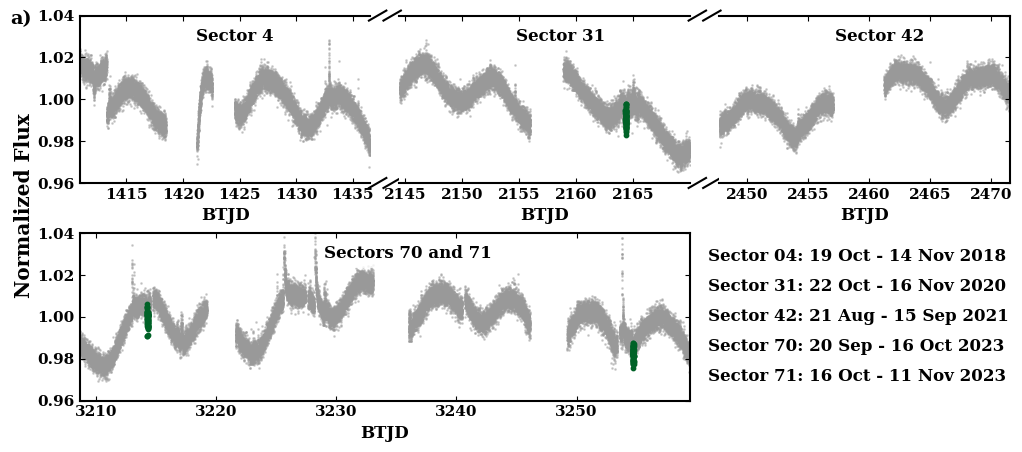

In [9]:
# Data setup for plotting
# ================================

t0 = 2459164.3524 - 2457000
per = 40.3834187
duration = 2.148 / 24

# Grouping
group1 = [4, 31, 42]
group2 = [70, 71]
label = ['Sector 4', 'Sector 31', 'Sector 42',  'Sectors 70 and 71']

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, 3, wspace=0.0, hspace=0.15) # Adjusted wspace and hspace

# Define axes
ax4   = fig.add_subplot(gs[0, 0])
ax31  = fig.add_subplot(gs[0, 1])
ax42  = fig.add_subplot(gs[0, 2])
ax7071 = fig.add_subplot(gs[1, :2]) 
ax_text = fig.add_subplot(gs[1, 2])

upper_axes = [ax4, ax31, ax42]


plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})


# ---------Plotting Logic-----------

# Update labels to match the number of files (5 files, 5 labels)
# Note: Sector 70 and 71 will both use 'ax7071' but they need labels in the loop
full_labels = ['Sector 4', 'Sector 31', 'Sector 42', 'Sector 70', 'Sector 71']

axis_limits = {}

for f, s_num, s_lab in zip(sector_files, labels, full_labels):
    s_num = int(s_num)
    
    target_ax = None
    if s_num == 4: target_ax = ax4
    elif s_num == 31: target_ax = ax31
    elif s_num == 42: target_ax = ax42
    elif s_num in [70, 71]: target_ax = ax7071
    
    if target_ax is None: continue

    time, flux, err = tess_sector(f)
    
    # Track limits
    if target_ax not in axis_limits:
        axis_limits[target_ax] = [np.min(time), np.max(time)]
    else:
        axis_limits[target_ax][0] = min(axis_limits[target_ax][0], np.min(time))
        axis_limits[target_ax][1] = max(axis_limits[target_ax][1], np.max(time))

    phase = (time - t0 + 0.5*per) % per - 0.5*per
    in_transit = np.abs(phase) < duration / 2

    target_ax.plot(time, flux, ".", ms=2, color="0.6", alpha=0.4, zorder=1, rasterized=True)
    target_ax.scatter(time[in_transit], flux[in_transit], s=10, color=colors[9], zorder=3, rasterized=True)
    
    # Logic for labels: If it's the shared axis, only label it once or handle specifically
    if s_num != 71: # Avoid double labeling the shared axis
        display_lab = "Sectors 70 and 71" if s_num == 70 else s_lab
        target_ax.text(0.4, 0.85, display_lab, transform=target_ax.transAxes, 
                       fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Limits
for ax, limits in axis_limits.items():
    # Add a 1% margin so data isn't cut off by the spine
    margin = (limits[1] - limits[0]) * 0.001
    ax.set_xlim(limits[0] - margin, limits[1] + margin)
    
    # Re-apply bold formatting to all, including ax7071
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set_linewidth(1.5)
        ax.spines[side].set_visible(True) # Ensure they are visible for the bottom row
    ax.tick_params(axis='both', which='major', direction='in', labelsize=11, right=True, top=True)
    ax.set_ylim(0.96, 1.04)
    ax.set_xlabel("BTJD", fontsize=12)
    


# --------Formatting: Custom Broken Axis Style------------
    
# Use a slightly wider wspace to ensure the slashes have a home
gs.update(wspace=0.1, hspace=0.3)

for i, ax in enumerate(upper_axes):
    # Standard formatting
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set_linewidth(1.5)
        ax.spines[side].set_edgecolor('black')
    
    # Hide internal vertical spines
    ax.spines['right'].set_visible(i == 2) 
    ax.spines['left'].set_visible(i == 0)

    # Disable the ticks on the "open" sides
    # This removes the "thicks" between sectors
    ax.tick_params(axis='both', which='major', direction='in', labelsize=11,
                   top=True, 
                   right=(i == 2), 
                   left=(i == 0),
                   labelleft=(i == 0))

  
    d = 0.03       # Length of the slash
    slash_gap = 0.05 # Space between the two / /
    
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1.5, zorder=10, rasterized=True)

    if i < 2:
        # We define the x-position to be slightly outside the right edge (1.0)
        # This centers the // in the wspace gap
        x1 = 1.0 + (slash_gap / 2)
        x2 = 1.0 + (slash_gap * 1.5)

        # Bottom Right Double Slash
        ax.plot((x1-d, x1+d), (-d, +d), **kwargs)
        ax.plot((x2-d, x2+d), (-d, +d), **kwargs)

        # Top Right Double Slash
        ax.plot((x1-d, x1+d), (1-d, 1+d), **kwargs)
        ax.plot((x2-d, x2+d), (1-d, 1+d), **kwargs)

# Remove y-axis labels for the 2nd and 3rd plots
plt.setp(ax31.get_yticklabels(), visible=False)
plt.setp(ax42.get_yticklabels(), visible=False)


#-----Text in white panel-------
ax_text.axis('off') 
date_text = (
    'Sector 04: 19 Oct - 14 Nov 2018\n'
    'Sector 31: 22 Oct - 16 Nov 2020\n'
    'Sector 42: 21 Aug - 15 Sep 2021\n'
    'Sector 70: 20 Sep - 16 Oct 2023\n'
    'Sector 71: 16 Oct - 11 Nov 2023'
)

ax_text.text(-0.04, 0.5, date_text, fontsize=12, transform=ax_text.transAxes, 
             verticalalignment='center', linespacing=2.0, fontweight='bold')
ax_text.text(-2.44, 0.95, 'a)', fontsize=14, transform=ax.transAxes)

fig.supylabel("Normalized Flux", fontweight='bold', x=0.07)
# plt.savefig('TESS_sectors.pdf', dpi=300)
plt.show()